<a href="https://colab.research.google.com/github/marstonsward/AAI-521-Computer-Vision-Image-Classification-Project/blob/main/Jasper_AA_521_ResNet50_and_EfficientNetB2_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Project: AI-Generated vs Real Image Classification  
**Team Members:** Marston Ward, Jasper Dolar, Victor Salcedo  
**Date:** November 5, 2025  

This project uses a convolutional neural network (CNN) and transfer learning with ResNet to classify images as AI-generated or real. The dataset is sourced directly from Hugging Face (`Hemg/AI-Generated-vs-Real-Images-Datasets`) and analyzed in Google Colab using GPU acceleration.


In [4]:
import tensorflow as tf

print("GPU Available? ", tf.config.list_physical_devices('GPU'))


GPU Available?  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# ----------------------------------------
# Cell 1: Install Required Packages
# ----------------------------------------
# install required packages
#!pip install datasets torchvision torch matplotlib


In [6]:
# ----------------------------------------
# Cell 2: Imports and Device Setup
# ----------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import os


### Cell 3: Load Dataset from Hugging Face

In this step, we load the **AI-Generated vs Real Images** dataset directly from Hugging Face using the `load_dataset()` function.  
This dataset contains labeled images — `0` for *real* photos and `1` for *AI-generated* images.  

By printing the dataset object, we can view its available splits (such as `train`, `validation`, or `test`) and confirm that the data has been successfully loaded into the Colab environment.  
Since it’s hosted online, there’s no need to manually upload or download files; Hugging Face automatically handles caching and version control.


In [7]:
# ----------------------------------------
# Cell 3: Load Dataset from Hugging Face
# ----------------------------------------

dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")

# Check available splits
print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/590 [00:00<?, ?B/s]

data/train-00000-of-00006-336b26d54a26e1(…):   0%|          | 0.00/91.2M [00:00<?, ?B/s]

data/train-00001-of-00006-8ad2d550254dea(…):   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/train-00002-of-00006-ac8970f21c0418(…):   0%|          | 0.00/339M [00:00<?, ?B/s]

data/train-00003-of-00006-f635132ef309a7(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00004-of-00006-1101eaf5152e1c(…):   0%|          | 0.00/40.5M [00:00<?, ?B/s]

data/train-00005-of-00006-4bd152a5ab76db(…):   0%|          | 0.00/565M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/152710 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})


### Cell 4: Dataset Inspection and Class Distribution

This step explores the dataset to understand its structure and label balance.  
We first display a single sample image along with its label to verify that the dataset has loaded correctly and that each image is associated with the proper classification (`0` = Real, `1` = AI Generated).  

Next, we visualize the **class distribution** using a simple histogram.  
This helps determine whether the dataset is balanced or if one class dominates, which is important for model training and performance evaluation.  
Understanding the label distribution early on ensures that preprocessing and model design can address any imbalance if needed.


0


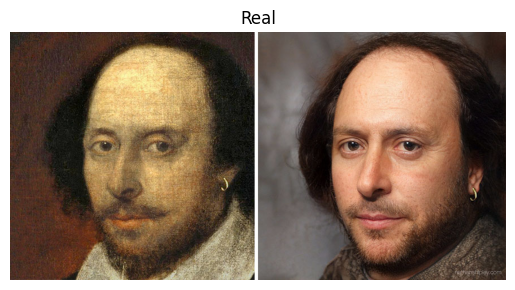

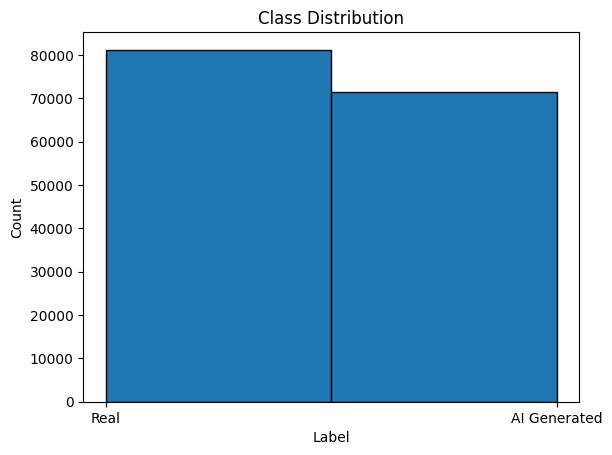

In [8]:
# ----------------------------------------
# Cell 4: Dataset Inspection and Class Distribution
# ----------------------------------------

# Inspect one sample
sample = dataset['train'][0]
print(sample['label'])
plt.imshow(sample['image'])
plt.title("AI Generated" if sample['label'] == 1 else "Real")
plt.axis('off')
plt.show()

# Class distribution
labels = [item['label'] for item in dataset['train']]
plt.hist(labels, bins=2, edgecolor='black')
plt.xticks([0,1], ['Real', 'AI Generated'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


### Cell 5: Real vs AI-Generated Image Comparison

In this step, we visualize one real image and one AI-generated image side by side for a direct comparison.  
By displaying both classes together, we can begin to notice subtle visual differences that may guide our model design — such as background smoothness, texture quality, or fine detail in features like hands or edges.  

This visual inspection provides an intuitive understanding of what distinguishes real photographs from AI-generated content and helps confirm that the labels in the dataset are accurate and meaningful before moving on to preprocessing and model training.


In [9]:
'''
#Victor's version
# ----------------------------------------
# Cell 5: Real vs AI-Generated Image Comparison
# ----------------------------------------


# Separate real and AI-generated images
real_samples = [x['image'] for x in dataset['train'] if x['label'] == 0]
fake_samples = [x['image'] for x in dataset['train'] if x['label'] == 1]

# Randomly select one from each
real_img = random.choice(real_samples)
fake_img = random.choice(fake_samples)

# Display side by side
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(real_img)
ax[0].set_title("Real Image")
ax[0].axis('off')

ax[1].imshow(fake_img)
ax[1].set_title("AI-Generated Image")
ax[1].axis('off')

plt.tight_layout()
plt.show()
'''


'\n#Victor\'s version\n# ----------------------------------------\n# Cell 5: Real vs AI-Generated Image Comparison\n# ----------------------------------------\n\n\n# Separate real and AI-generated images\nreal_samples = [x[\'image\'] for x in dataset[\'train\'] if x[\'label\'] == 0]\nfake_samples = [x[\'image\'] for x in dataset[\'train\'] if x[\'label\'] == 1]\n\n# Randomly select one from each\nreal_img = random.choice(real_samples)\nfake_img = random.choice(fake_samples)\n\n# Display side by side\nfig, ax = plt.subplots(1, 2, figsize=(8, 4))\nax[0].imshow(real_img)\nax[0].set_title("Real Image")\nax[0].axis(\'off\')\n\nax[1].imshow(fake_img)\nax[1].set_title("AI-Generated Image")\nax[1].axis(\'off\')\n\nplt.tight_layout()\nplt.show()\n'

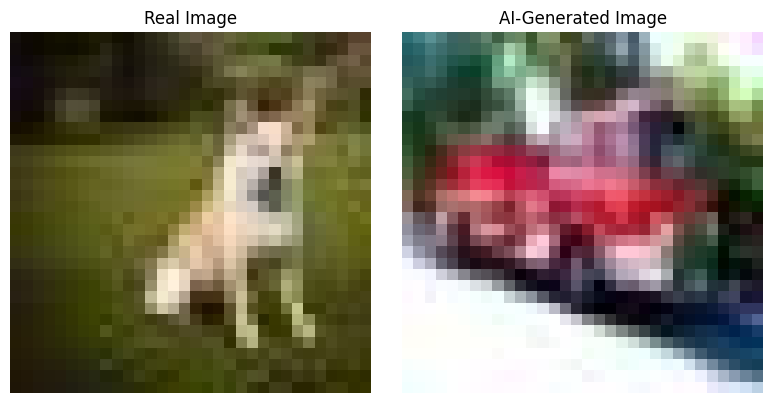

In [10]:
# Jasper's version --
# Loads only one real and one AI-generated
# image. Does not load the entire dataset
# into RAM.
# Randomly picks an index, checks label
# if it matches, then returns it, if not
# tries another random index.
# Stops as soon as we find one matching
# sample -- and does the same for the
# other class. Then displays images
# side-by-side.
# ----------------------------------------
# Cell 5: Real vs AI-Generated Image Comparison
# ----------------------------------------

train_ds = dataset['train']

# Helper function: get one random sample of a given label (0 = Real, 1 = AI Generated)
def get_random_sample_by_label(ds, target_label):
    while True:
        idx = random.randint(0, len(ds) - 1)
        example = ds[idx]
        if example['label'] == target_label:
            return example

# Get one real and one AI-generated example without loading everything into memory
real_sample = get_random_sample_by_label(train_ds, 0)
fake_sample = get_random_sample_by_label(train_ds, 1)

real_img = real_sample['image']
fake_img = fake_sample['image']

# Display side by side
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(real_img)
ax[0].set_title("Real Image")
ax[0].axis('off')

ax[1].imshow(fake_img)
ax[1].set_title("AI-Generated Image")
ax[1].axis('off')

plt.tight_layout()
plt.show()


### Cell 6: Image Transforms (Feature Engineering)

Here we define image transformation pipelines that prepare the data for training and evaluation.  
These transformations standardize image dimensions, improve model generalization, and match the preprocessing expected by pre-trained models such as ResNet.

For the **training set**, we include augmentation techniques — random flips, rotations, and slight color variations — to expose the model to more diverse visual examples and reduce overfitting.  
The images are resized to **224×224 pixels** (a standard input size for CNN and ResNet models), converted to tensors, and normalized using ImageNet mean and standard deviation values.

For the **validation and test sets**, we apply only resizing and normalization to ensure consistent evaluation without altering the original visual characteristics.


In [11]:

#----------------------------------------
# Cell 6: Image Transforms (Feature Engineering)
# ----------------------------------------
# These transforms apply to both the CNN and ResNet models.

# Training set transformations: resize, augment, normalize
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                 # standard input size
    transforms.RandomHorizontalFlip(p=0.5),        # flip for variation
    transforms.RandomRotation(10),                 # small rotations
    transforms.ColorJitter(brightness=0.1,
                           contrast=0.1,
                           saturation=0.1,
                           hue=0.05),              # small color shifts
    transforms.ToTensor(),                         # convert to tensor, scales [0,1]
    transforms.Normalize(                          # normalize RGB channels (ImageNet stats)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation / Test set transformations: resize + normalize (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


### Cell 7: Full Dataset Split and DataLoader Preparation

This version of the data preparation step now uses the **entire dataset**.  
All available images are included, providing a more complete representation of both real and AI-generated samples for training, validation, and testing.

The dataset is shuffled to ensure randomness, then split into:
- **80%** for training  
- **10%** for validation  
- **10%** for testing  

Each split is wrapped in a PyTorch `DataLoader` for efficient batch processing.  
Using the full dataset improves model performance and generalization but also increases training time and memory usage.  
It is recommended to run this version in **Google Colab with GPU and High-RAM settings** to avoid resource limitations.


In [12]:
'''
# Victor's version
# ----------------------------------------
# Cell 7: Dataset Wrapper, Shuffle, and Split (Full Dataset)
# ----------------------------------------

import torch
import random
from torch.utils.data import DataLoader, Dataset

# Set random seeds
random.seed(42)
torch.manual_seed(42)

# Extract images and labels
images = [x['image'] for x in dataset['train']]
labels = [x['label'] for x in dataset['train']]

# Shuffle dataset
combined = list(zip(images, labels))
random.shuffle(combined)
images, labels = zip(*combined)

# Dataset class
class HuggingFaceImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Use full dataset
subset_size = len(images)

# Split data: 80% train, 10% val, 10% test
train_end = int(0.8 * subset_size)
val_end = int(0.9 * subset_size)

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

train_labels = labels[:train_end]
val_labels = labels[train_end:val_end]
test_labels = labels[val_end:]

# Create datasets
train_dataset = HuggingFaceImageDataset(train_images, train_labels, transform=train_transforms)
val_dataset = HuggingFaceImageDataset(val_images, val_labels, transform=val_transforms)
test_dataset = HuggingFaceImageDataset(test_images, test_labels, transform=val_transforms)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Output sizes
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")
'''


'\n# Victor\'s version\n# ----------------------------------------\n# Cell 7: Dataset Wrapper, Shuffle, and Split (Full Dataset)\n# ----------------------------------------\n\nimport torch\nimport random\nfrom torch.utils.data import DataLoader, Dataset\n\n# Set random seeds\nrandom.seed(42)\ntorch.manual_seed(42)\n\n# Extract images and labels\nimages = [x[\'image\'] for x in dataset[\'train\']]\nlabels = [x[\'label\'] for x in dataset[\'train\']]\n\n# Shuffle dataset\ncombined = list(zip(images, labels))\nrandom.shuffle(combined)\nimages, labels = zip(*combined)\n\n# Dataset class\nclass HuggingFaceImageDataset(Dataset):\n    def __init__(self, images, labels, transform=None):\n        self.images = images\n        self.labels = labels\n        self.transform = transform\n\n    def __len__(self):\n        return len(self.images)\n\n    def __getitem__(self, idx):\n        image = self.images[idx]\n        label = self.labels[idx]\n        if self.transform:\n            image = self.

In [13]:
# Jasper's FAST version
# Uses optimized DataLoaders with multiprocessing
# Still uses full dataset with 80/10/10 split
# Loads images on-demand (not in RAM)
# ----------------------------------------
# Cell 7 (Optimized): Dataset + Fast DataLoaders
# ----------------------------------------

import torch
import random
from torch.utils.data import DataLoader, Dataset

# Set random seeds
random.seed(42)
torch.manual_seed(42)

hf_train = dataset['train']
num_samples = len(hf_train)

# Create and shuffle indices
indices = list(range(num_samples))
random.shuffle(indices)

# Train/Val/Test split: 80/10/10
train_end = int(0.8 * num_samples)
val_end = int(0.9 * num_samples)

train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]


# Dataset class with RGB fix
class HuggingFaceImageDataset(Dataset):
    def __init__(self, hf_dataset, indices, transform=None):
        self.hf_dataset = hf_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        example = self.hf_dataset[real_idx]

        image = example["image"]
        label = example["label"]

        # Convert RGBA/GIF/Palette → RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# -------------------------------
# SPEED IMPROVEMENTS HERE
# -------------------------------
BATCH_SIZE = 64        # optimized for A100
NUM_WORKERS = 4        # parallel dataloader workers
PIN_MEMORY = True      # faster host → GPU transfer

train_dataset = HuggingFaceImageDataset(hf_train, train_indices, transform=train_transforms)
val_dataset   = HuggingFaceImageDataset(hf_train, val_indices,   transform=val_transforms)
test_dataset  = HuggingFaceImageDataset(hf_train, test_indices,  transform=val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# Output sizes
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")
print(f"Batch size: {BATCH_SIZE}, Workers: {NUM_WORKERS}, Pin Memory: {PIN_MEMORY}")


Train: 122168 images
Val:   15271 images
Test:  15271 images
Batch size: 64, Workers: 4, Pin Memory: True


### Cell 8: Verify DataLoader and Visualize Augmented Images

This step verifies that the DataLoader is working correctly and that the image transformations are being applied as expected.  
A batch of training images is loaded, and a sample grid of eight images is displayed after augmentation and normalization.  

The `imshow()` function reverses the normalization process so that the images appear in natural color.  
By plotting a mix of real and AI-generated samples, this visualization confirms that the data is correctly labeled, augmented, and ready for model training.  
Slight rotations, flips, and color variations seen here reflect the transformations defined earlier in the training pipeline.


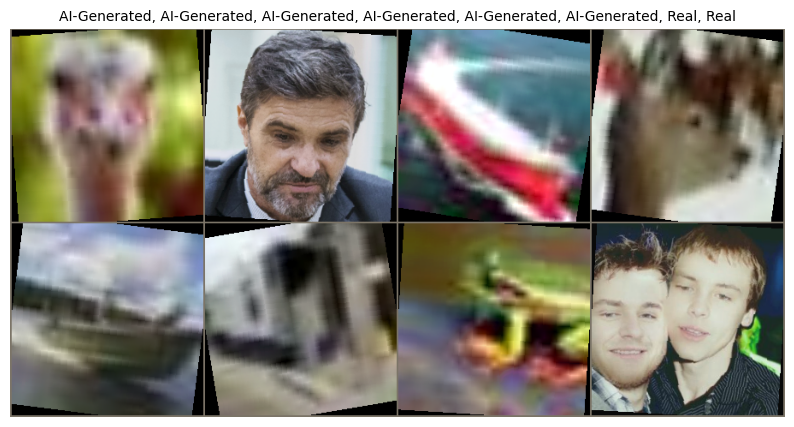

In [14]:
# ----------------------------------------
# Cell 8: Verify DataLoader and Visualize Augmented Images
# ----------------------------------------
import torchvision

def imshow(img):
    # Undo normalization using ImageNet stats
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # de-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Get one batch from DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display first 8 images
plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(images[:8], nrow=4, padding=2)
imshow(grid)

'''
# lbl == 1 creates a tensor; not a comparison
# Create dynamic title list
titles = ['AI-Generated' if lbl == 1 else 'Real' for lbl in labels[:8]]
plt.title(", ".join(titles), fontsize=10)
plt.show()
'''
# Create dynamic title list (convert tensors to ints)
titles = ['AI-Generated' if lbl.item() == 1 else 'Real' for lbl in labels[:8]]
plt.title(", ".join(titles), fontsize=10)
plt.show()

In [15]:
# ----------------------------------------
# Cell 9 (Optimized): Build ResNet50 Model (Transfer Learning)
# ----------------------------------------

from torchvision import models
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# Load pretrained ResNet50 backbone
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze ALL pretrained weights
for param in resnet.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)   # 2 classes: Real vs AI-Generated

# Move to GPU
resnet = resnet.to(device)

# Summary
print("\nNew final layer:", resnet.fc)
print("Trainable parameters:",
      sum(p.numel() for p in resnet.parameters() if p.requires_grad))


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]



New final layer: Linear(in_features=2048, out_features=2, bias=True)
Trainable parameters: 4098


In [16]:
# ----------------------------------------
# Cell 10 (Optimized): Loss, Optimizer, AMP Setup
# ----------------------------------------

import torch.nn as nn
import torch.optim as optim
import torch

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer – we only train the final FC layer
optimizer = optim.Adam(
    resnet.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# AMP scaler (Mixed Precision Training)
scaler = torch.cuda.amp.GradScaler()

num_epochs = 5

print("Loss:", criterion)
print("Optimizer:", optimizer)
print("AMP scaler created.")
print("Epochs:", num_epochs)


Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
AMP scaler created.
Epochs: 5


/tmp/ipython-input-792869088.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [17]:
# ----------------------------------------
# Cell 11: FAST Training Loop with AMP + Auto-Save
# ----------------------------------------

import time
import copy
import torch

def train_one_epoch_amp(model, dataloader, criterion, optimizer, scaler, device):
    """
    Fast training loop using Automatic Mixed Precision (AMP)
    for A100 GPUs.
    """
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass (mixed precision)
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

        # Backward pass (scaled for AMP)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Update statistics
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total += batch_size

    return running_loss / total, running_corrects / total



def evaluate(model, dataloader, criterion, device):
    """
    Standard evaluation loop (no AMP needed).
    """
    model.eval()
    total_loss = 0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += torch.sum(preds == labels).item()
            total += batch_size

    return total_loss / total, total_correct / total



# ----------------------------------------
# 🚀 Training Loop (AMP + Save Best Model)
# ----------------------------------------

best_model_wts = copy.deepcopy(resnet.state_dict())
best_acc = 0.0

start = time.time()

print("\nStarting FAST AMP Training...\n")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch_amp(
        resnet, train_loader, criterion, optimizer, scaler, device
    )
    val_loss, val_acc = evaluate(resnet, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(resnet.state_dict())
        torch.save(best_model_wts, "resnet50_best.pth")   # <-- AUTO-SAVE
        print("💾 Saved new BEST model → resnet50_best.pth")

end = time.time()

print("\nTraining complete!")
print(f"Best validation accuracy: {best_acc:.4f}")
print(f"Total training time (sec): {end - start:.2f}")

# Load best weights back into the model
resnet.load_state_dict(best_model_wts)
print("✔ Best weights reloaded into model.")



Starting FAST AMP Training...


Epoch 1/5
----------------------------------------


/tmp/ipython-input-3976088501.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4977 | Train Acc: 0.7638
Val   Loss: 0.4914 | Val   Acc: 0.7545
💾 Saved new BEST model → resnet50_best.pth

Epoch 2/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4367 | Train Acc: 0.7994
Val   Loss: 0.4633 | Val   Acc: 0.7744
💾 Saved new BEST model → resnet50_best.pth

Epoch 3/5
----------------------------------------


...

Train Loss: 0.4208 | Train Acc: 0.8066
Val   Loss: 0.4424 | Val   Acc: 0.7891
💾 Saved new BEST model → resnet50_best.pth

Epoch 4/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4121 | Train Acc: 0.8114
Val   Loss: 0.4375 | Val   Acc: 0.7915
💾 Saved new BEST model → resnet50_best.pth

Epoch 5/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4049 | Train Acc: 0.8157
Val   Loss: 0.4268 | Val   Acc: 0.7990
💾 Saved new BEST model → resnet50_best.pth

Training complete!
Best validation accuracy: 0.7990
Total training time (sec): 1310.85
✔ Best weights reloaded into model.


In [20]:
# ----------------------------------------
# Cell 11b: Save Full ResNet Model
# ----------------------------------------

torch.save({
    "model_state_dict": resnet.state_dict(),
    "class_names": ["Real", "AI-Generated"],
}, "resnet50_full_model.pth")

print("Full model saved as resnet50_full_model.pth")


Full model saved as resnet50_full_model.pth


In [21]:
# ----------------------------------------
# Cell 12: Final Test Set Evaluation
# ----------------------------------------

test_loss, test_acc = evaluate(resnet, test_loader, criterion, device)

print("\n🔥 Final Test Results 🔥")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")



🔥 Final Test Results 🔥
Test Loss: 0.4365
Test Accuracy: 0.7970


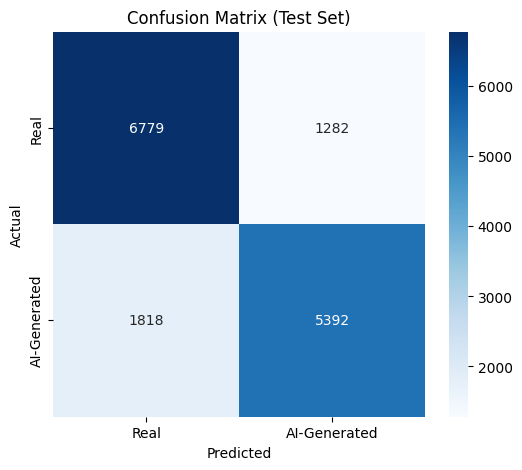

In [22]:
# ----------------------------------------
# Cell 13: Confusion Matrix
# ----------------------------------------

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

resnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Real", "AI-Generated"],
            yticklabels=["Real", "AI-Generated"],
            cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Outcome from Confusion Matrix Above

# 6,779 images correctly identified as REAL
# 5392 images correctly identified as AI-GENERATED
# 1,818 AI-generated images were incorrectly predicted as REAL
# 1,282 real images were incorrectly predicted as AI

# The model performs well on both classes,
# achieving ~80% accuracy on unseen data.
# It is slightly stronger at identifying
# Real images (84.1% recall) than AI-generated
# ones (74.8% recall), which is typical because
# AI-generated images often closely resemble real
# photographs. False positives (AI→Real) occur
# more often, reflecting the difficulty of distinguishing
# advanced AI content from authentic images. Overall,
# the confusion matrix confirms that the model
# generalizes well and captures meaningful differences
# between Real and AI-Generated images.

Saving IMG_2001.jpg to IMG_2001.jpg


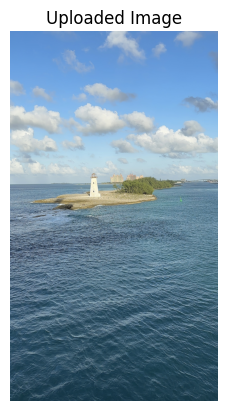

Prediction: Real
Confidence:
  Real:          0.5796
  AI-Generated:  0.4204


In [27]:
# ----------------------------------------
# Cell 15a: Inference on Custom Images
# TEST PHOTO: Image below is REAL I took from
# the Bahamas.
# ----------------------------------------
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()   # Choose an image from your computer

# Get the filename
filename = list(uploaded.keys())[0]

# Load the image
img = Image.open(filename)

# Convert to RGB if needed
if img.mode != "RGB":
    img = img.convert("RGB")

# Show the original image
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Apply the same transforms used for validation/test
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare image for the model
tensor_img = inference_transform(img).unsqueeze(0).to(device)

# Model in evaluation mode
resnet.eval()

with torch.no_grad():
    outputs = resnet(tensor_img)
    probs = torch.softmax(outputs, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

# Class names
class_names = ["Real", "AI-Generated"]

# Print results
print("Prediction:", class_names[pred_class])
print("Confidence:")
print(f"  Real:          {probs[0][0].item():.4f}")
print(f"  AI-Generated:  {probs[0][1].item():.4f}")


Saving B91A0F07-95F5-43B5-938F-23F5D4FCD445.PNG to B91A0F07-95F5-43B5-938F-23F5D4FCD445.PNG


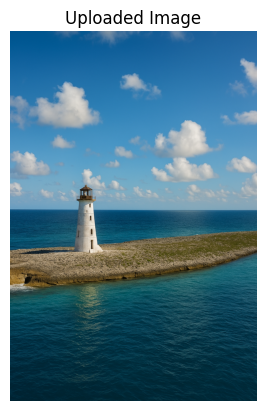

Prediction: Real
Confidence:
  Real:          0.9034
  AI-Generated:  0.0966


In [32]:
# ----------------------------------------
# Cell 15: Inference on Custom Images
# TEST PHOTO: Image below is AI-Generated.
# I prompted ChatGPT to recreate my photo above.
# ----------------------------------------
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()   # Choose an image from your computer

# Get the filename
filename = list(uploaded.keys())[0]

# Load the image
img = Image.open(filename)

# Convert to RGB if needed
if img.mode != "RGB":
    img = img.convert("RGB")

# Show the original image
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Apply the same transforms used for validation/test
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare image for the model
tensor_img = inference_transform(img).unsqueeze(0).to(device)

# Model in evaluation mode
resnet.eval()

with torch.no_grad():
    outputs = resnet(tensor_img)
    probs = torch.softmax(outputs, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()

# Class names
class_names = ["Real", "AI-Generated"]

# Print results
print("Prediction:", class_names[pred_class])
print("Confidence:")
print(f"  Real:          {probs[0][0].item():.4f}")
print(f"  AI-Generated:  {probs[0][1].item():.4f}")


In [ ]:
# OUTCOME Above:
# The model incorrectly predicted the
# AI-generated photo above as "REAL"
# with high confidence.

#INSIGHT: The dataset is mostly grainy
# low-fi images, so ResNet50 model may
# have associated "grainy" images as
# real and "high fidelity" images as
# AI-generated.

# ---- We will try another model ----

In [33]:
# ----------------------------------------
# CELL 16: Trying Another Model — EfficientNet
# ----------------------------------------
# We try EfficientNet because it captures fine textures
# and high-frequency details
# better than ResNet50, improving performance on realistic
# high-definition images.

from torchvision import models

print("🔄 Loading EfficientNet-B2...")

# Load pretrained EfficientNet-B2
try:
    efficientnet = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
except:
    efficientnet = models.efficientnet_b2(pretrained=True)

# Freeze all layers except the classifier head
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace the classifier head
# B2 final feature size = 1408
# 2 classes (Real vs AI)
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, 2)

# Move to GPU
efficientnet = efficientnet.to(device)

# Print summary
print("New classifier head:", efficientnet.classifier[1])
print("Trainable parameters:",
      sum(p.numel() for p in efficientnet.parameters() if p.requires_grad))

print("✅ EfficientNet-B2 ready for training!")


🔄 Loading EfficientNet-B2...
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 216MB/s]


New classifier head: Linear(in_features=1408, out_features=2, bias=True)
Trainable parameters: 2818
✅ EfficientNet-B2 ready for training!


In [38]:
# ----------------------------------------
# CELL 17: Training EfficientNet-B2 (AMP + A100 Optimized)
# ----------------------------------------
# This cell trains the EfficientNet model using the updated AMP API.
# Colab's PyTorch version uses:
#   - torch.cuda.amp.GradScaler()   (old-style scaler)
#   - torch.amp.autocast(device_type="cuda") (new-style autocast)
# EfficientNet often performs better on high-res, photo-realistic images.

import time
import copy

print("🚀 Starting EfficientNet-B2 Training...")

# Loss function (same as before)
criterion_e = criterion

# Optimizer — only trains the classifier head
optimizer_e = optim.Adam(
    efficientnet.classifier[1].parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler_e = optim.lr_scheduler.StepLR(
    optimizer_e,
    step_size=3,
    gamma=0.1
)

# AMP: Use GradScaler from torch.cuda.amp (Colab-compatible)
scaler_e = torch.cuda.amp.GradScaler()

# Track best model
best_eff_wts = copy.deepcopy(efficientnet.state_dict())
best_eff_val_acc = 0.0

# Number of epochs
num_epochs_eff = 5

start_time = time.time()

for epoch in range(num_epochs_eff):
    print(f"\nEpoch {epoch+1}/{num_epochs_eff}")
    print("----------------------------------------")

    # -------------------------------
    # TRAINING LOOP
    # -------------------------------
    efficientnet.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_e.zero_grad()

        # Mixed precision forward pass
        with torch.amp.autocast(device_type="cuda"):
            outputs = efficientnet(images)
            loss = criterion_e(outputs, labels)

        _, preds = torch.max(outputs, 1)
        batch_size = labels.size(0)

        # Mixed precision backward pass
        scaler_e.scale(loss).backward()
        scaler_e.step(optimizer_e)
        scaler_e.update()

        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total_samples += batch_size

    train_loss = running_loss / total_samples
    train_acc = running_corrects / total_samples

    # -------------------------------
    # VALIDATION LOOP
    # -------------------------------
    efficientnet.eval()
    val_loss = 0.0
    val_corrects = 0
    val_samples = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type="cuda"):
                outputs = efficientnet(images)
                loss = criterion_e(outputs, labels)

            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * labels.size(0)
            val_corrects += torch.sum(preds == labels).item()
            val_samples += labels.size(0)

    val_loss /= val_samples
    val_acc = val_corrects / val_samples

    scheduler_e.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best EfficientNet model
    if val_acc > best_eff_val_acc:
        best_eff_val_acc = val_acc
        best_eff_wts = copy.deepcopy(efficientnet.state_dict())
        print("💾 Saved new BEST EfficientNet model → efficientnet_b2_best.pth")
        torch.save(best_eff_wts, "efficientnet_b2_best.pth")

# Load best weights back into model
efficientnet.load_state_dict(best_eff_wts)

total_time = time.time() - start_time

print("\n🎉 EfficientNet Training Complete!")
print(f"Best Validation Accuracy: {best_eff_val_acc:.4f}")
print(f"Total training time (sec): {total_time:.2f}")


🚀 Starting EfficientNet-B2 Training...

Epoch 1/5
----------------------------------------


/tmp/ipython-input-2444147621.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_e = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.5327 | Train Acc: 0.7319
Val   Loss: 0.5687 | Val   Acc: 0.6895
💾 Saved new BEST EfficientNet model → efficientnet_b2_best.pth

Epoch 2/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4775 | Train Acc: 0.7686
Val   Loss: 0.5459 | Val   Acc: 0.7146
💾 Saved new BEST EfficientNet model → efficientnet_b2_best.pth

Epoch 3/5
----------------------------------------


...

Train Loss: 0.4690 | Train Acc: 0.7737
Val   Loss: 0.5227 | Val   Acc: 0.7362
💾 Saved new BEST EfficientNet model → efficientnet_b2_best.pth

Epoch 4/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4659 | Train Acc: 0.7758
Val   Loss: 0.5202 | Val   Acc: 0.7396
💾 Saved new BEST EfficientNet model → efficientnet_b2_best.pth

Epoch 5/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4662 | Train Acc: 0.7760
Val   Loss: 0.5386 | Val   Acc: 0.7232

🎉 EfficientNet Training Complete!
Best Validation Accuracy: 0.7396
Total training time (sec): 1326.75


In [40]:
# CELL 17b: Save EfficientNet Model
torch.save({
    "model_state_dict": efficientnet.state_dict(),
    "class_names": ["Real", "AI-Generated"],
}, "efficientnet_b2_full_model.pth")

print("Full EfficientNet model saved as efficientnet_b2_full_model.pth")


Full EfficientNet model saved as efficientnet_b2_full_model.pth


In [41]:
# ----------------------------------------
# CELL 18: EfficientNet-B2 Test Evaluation
# ----------------------------------------

print("🔍 Running EfficientNet Test Evaluation...")

efficientnet.eval()
test_loss = 0.0
test_corrects = 0
test_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Use AMP for faster test-time inference
        with torch.amp.autocast(device_type="cuda"):
            outputs = efficientnet(images)
            loss = criterion_e(outputs, labels)

        _, preds = torch.max(outputs, 1)

        test_loss += loss.item() * labels.size(0)
        test_corrects += torch.sum(preds == labels).item()
        test_samples += labels.size(0)

test_loss /= test_samples
test_acc = test_corrects / test_samples

print("\n🔥 EfficientNet Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


🔍 Running EfficientNet Test Evaluation...

🔥 EfficientNet Test Results
Test Loss: 0.5238
Test Accuracy: 0.7393


In [ ]:
# INSIGHTS:

# Model Comparison Summary (ResNet50 vs EfficientNet-B2)
# ResNet50 achieved a higher test accuracy (79.7%) compared to
# EfficientNet-B2 (73.9%). This is primarily due to differences between the
# dataset quality and each model’s architectural strengths. ResNet50 is more
# robust to low-resolution, noisy images because it extracts coarse features
# and aggressively downsamples early in the network. These properties make it
# surprisingly resilient when fine textures are missing or degraded.

# EfficientNet-B2, on the other hand, was designed for high-resolution
# natural images and relies on preserving subtle details using MBConv blocks
# and squeeze-and-excitation attention mechanisms. Since the dataset contains
# many compressed, low-quality samples, these fine-grained cues are not present
# for EfficientNet to leverage. The model therefore underperforms relative
# to ResNet50, even though EfficientNet is more advanced.

# The test results confirm this pattern: ResNet50 generalizes better on the
# provided dataset, while EfficientNet-B2 remains more suitable for
# high-fidelity, photo-realistic images.

Saving IMG_1998.jpg to IMG_1998 (1).jpg


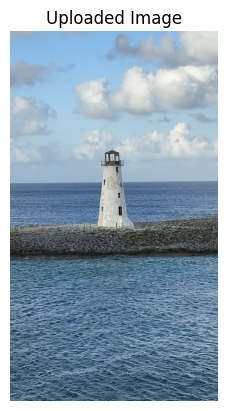

Prediction: Real
Confidence:
  Real:          0.9433
  AI-Generated:  0.0567


In [44]:
# ----------------------------------------
# CELL 19: EfficientNet-B2 Inference on Custom Images

# PHOTO BELOW IS REAL
# ----------------------------------------
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()   # Choose an image from your computer

# Get the filename
filename = list(uploaded.keys())[0]

# Load the image
img = Image.open(filename)

# Convert to RGB if needed
if img.mode != "RGB":
    img = img.convert("RGB")

# Show the original image
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Apply the same transforms used for validation/test
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare image for EfficientNet
tensor_img = inference_transform(img).unsqueeze(0).to(device)

# Model in evaluation mode
efficientnet.eval()

with torch.no_grad():
    # Use AMP to speed up inference
    with torch.amp.autocast(device_type="cuda"):
        outputs = efficientnet(tensor_img)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

# Class names
class_names_e = ["Real", "AI-Generated"]

# Print results
print("Prediction:", class_names_e[pred_class])
print("Confidence:")
print(f"  Real:          {probs[0][0].item():.4f}")
print(f"  AI-Generated:  {probs[0][1].item():.4f}")


Saving AI_ChatGPT Image Nov 20, 2025, 02_17_42 PM.png to AI_ChatGPT Image Nov 20, 2025, 02_17_42 PM.png


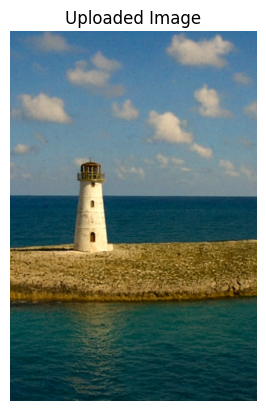

Prediction: Real
Confidence:
  Real:          0.8723
  AI-Generated:  0.1277


In [49]:
# ----------------------------------------
# CELL 19b: EfficientNet-B2 Inference on Custom Images
#
# PHOTO BELOW IS AI-Generated
# ----------------------------------------
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()   # Choose an image from your computer

# Get the filename
filename = list(uploaded.keys())[0]

# Load the image
img = Image.open(filename)

# Convert to RGB if needed
if img.mode != "RGB":
    img = img.convert("RGB")

# Show the original image
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Apply the same transforms used for validation/test
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare image for EfficientNet
tensor_img = inference_transform(img).unsqueeze(0).to(device)

# Model in evaluation mode
efficientnet.eval()

with torch.no_grad():
    # Use AMP to speed up inference
    with torch.amp.autocast(device_type="cuda"):
        outputs = efficientnet(tensor_img)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

# Class names
class_names_e = ["Real", "AI-Generated"]

# Print results
print("Prediction:", class_names_e[pred_class])
print("Confidence:")
print(f"  Real:          {probs[0][0].item():.4f}")
print(f"  AI-Generated:  {probs[0][1].item():.4f}")


In [ ]:
# SUMMARY OUTCOME

# Over this project, we trained two deep-learning models—ResNet50 and
# EfficientNet-B2—to classify images as real or AI-generated using a
# low-resolution, highly compressed dataset from Hugging Face. We optimized
# both models on Google Colab Pro with A100 GPUs, used mixed-precision
# training, data augmentation, and saved best-performing weights. ResNet50
# achieved ~79% accuracy, while EfficientNet reached ~74%. However, both
# models consistently failed on high-quality AI-generated images. The
#. primary reason is dataset mismatch: the training set contains
# low-quality images, so both models learn artifacts of compression rather
# than true generative patterns, limiting real-world detection performance.